<a href="https://colab.research.google.com/github/prathik002/DataScience-Lab/blob/main/Program_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (545, 13)

Data types:
 price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Missing values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate rows: 0

Numeric summary:
               price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141

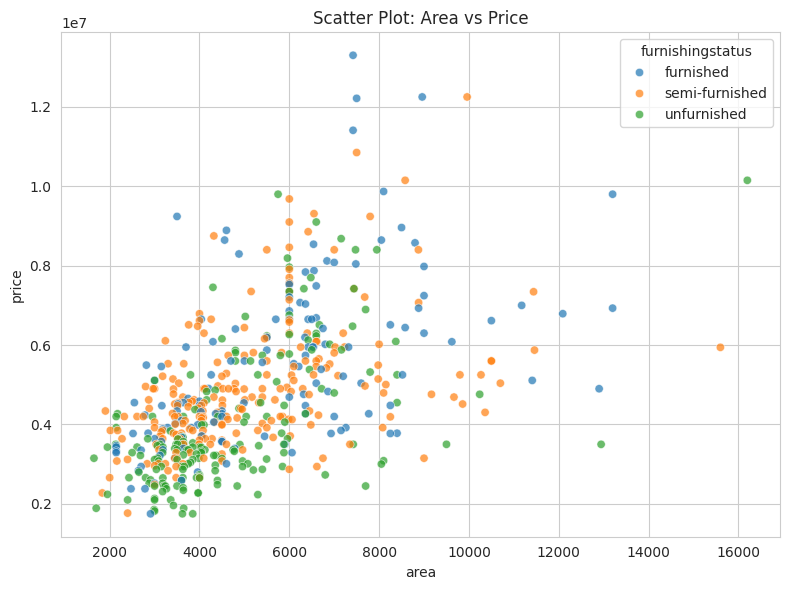

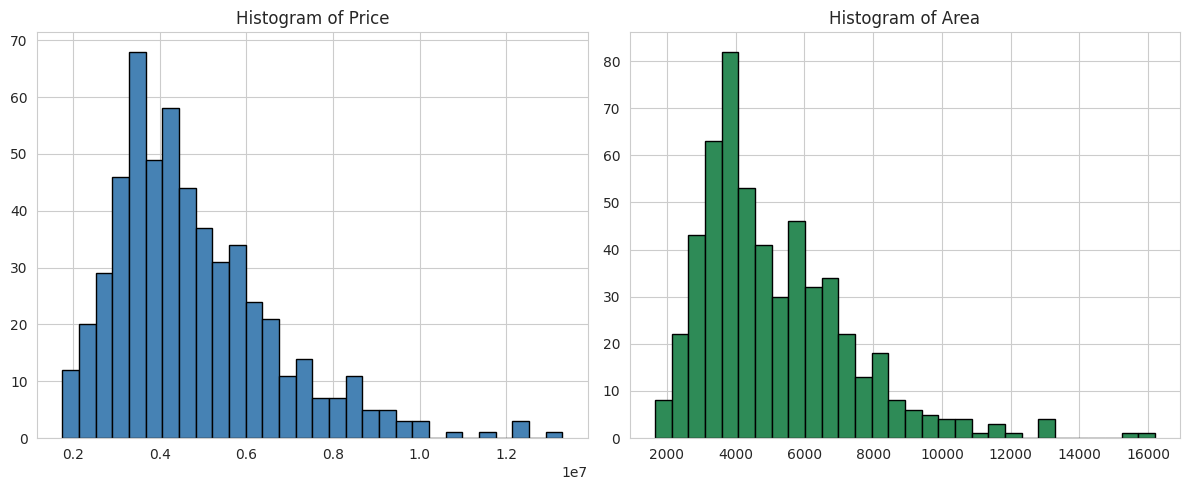

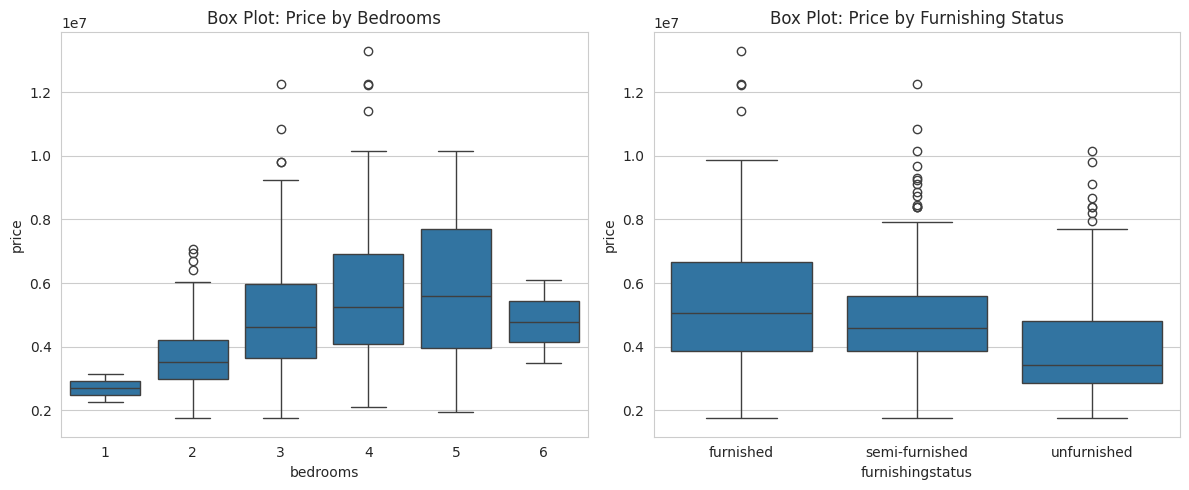

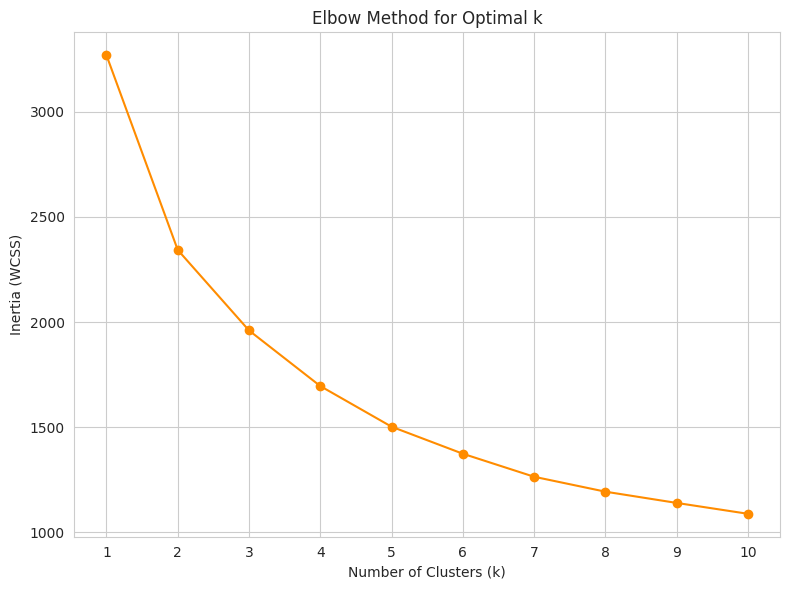

k=1: inertia=3270.00
k=2: inertia=2343.05
k=3: inertia=1959.71
k=4: inertia=1695.00
k=5: inertia=1501.47
k=6: inertia=1372.81
k=7: inertia=1263.21
k=8: inertia=1192.17
k=9: inertia=1138.63
k=10: inertia=1086.87

Cluster sizes:
 cluster
0    115
1    171
2     93
3    166
Name: count, dtype: int64

Cluster-wise means:
               price     area  bedrooms  bathrooms  stories  parking
cluster                                                            
0        7010738.61  6339.97      3.50       2.04     2.62     1.08
1        4137859.65  4041.35      3.32       1.13     2.16     0.25
2        5404827.96  7317.31      2.91       1.08     1.38     1.78
3        3502466.87  4255.23      2.26       1.04     1.11     0.28


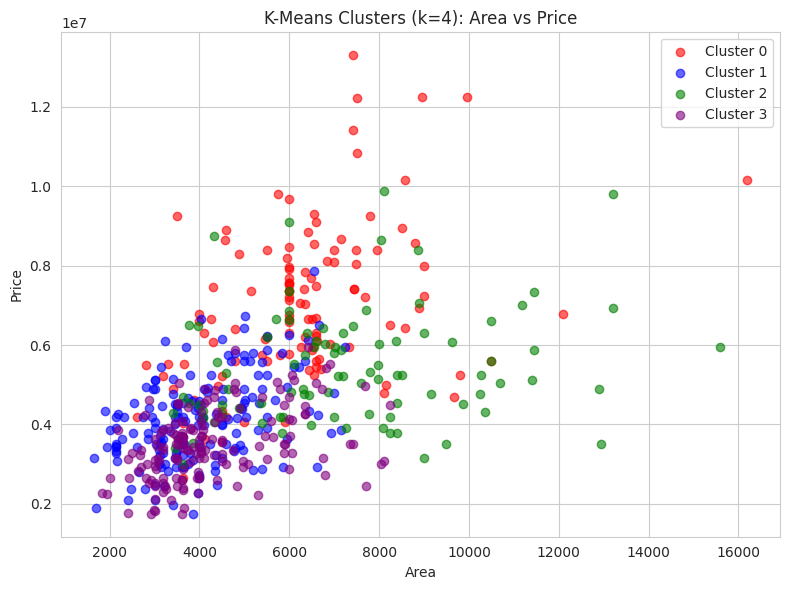

In [1]:
'''Program 18: Dataset: Housing_Price.csv
a) Conduct exploratory data analysis on the given dataset and report the details.
b) Visualize the analysis results using (i) scatter plot (ii) histogram & (iii) box plot.
c) Implement the K-Means clustering algorithm using the dataset. Try with different k values and plot the elbow graph for the k values.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")

# Load data
df = pd.read_csv("/content/Housing.csv")

# a) Exploratory Data Analysis
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nNumeric summary:\n", df.describe())
print("\nCategorical summary:\n", df.describe(include='object'))

numeric_df = df.select_dtypes(include=[np.number])
print("\nCorrelation matrix:\n", numeric_df.corr())

# b) Visualizations
# (i) Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="area", y="price", hue="furnishingstatus", alpha=0.7)
plt.title("Scatter Plot: Area vs Price")
plt.tight_layout()
plt.savefig("scatter_area_price.png", dpi=150)
plt.show()

# (ii) Histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df["price"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Histogram of Price")
axes[1].hist(df["area"], bins=30, color="seagreen", edgecolor="black")
axes[1].set_title("Histogram of Area")
plt.tight_layout()
plt.savefig("histogram_price_area.png", dpi=150)
plt.show()

# (iii) Box plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="bedrooms", y="price", ax=axes[0])
axes[0].set_title("Box Plot: Price by Bedrooms")
sns.boxplot(data=df, x="furnishingstatus", y="price", ax=axes[1])
axes[1].set_title("Box Plot: Price by Furnishing Status")
plt.tight_layout()
plt.savefig("boxplot_price.png", dpi=150)
plt.show()

# c) K-Means Clustering
features = df[["price", "area", "bedrooms", "bathrooms", "stories", "parking"]]
X = StandardScaler().fit_transform(features)
# Elbow method
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(list(K_range), inertias, marker='o', color='darkorange')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(list(K_range))
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=150)
plt.show()

for k, i in zip(K_range, inertias):
    print(f"k={k}: inertia={i:.2f}")

# Final model with chosen k
optimal_k = 4
km_final = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X)

print("\nCluster sizes:\n", df["cluster"].value_counts().sort_index())
print("\nCluster-wise means:\n",
      df.groupby("cluster")[["price", "area", "bedrooms", "bathrooms", "stories", "parking"]].mean().round(2))

plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'purple']
for c in range(optimal_k):
    subset = df[df["cluster"] == c]
    plt.scatter(subset["area"], subset["price"], label=f"Cluster {c}", alpha=0.6, color=colors[c])
plt.title(f"K-Means Clusters (k={optimal_k}): Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()